# Identifying Latent Academic Skill Dimensions with PROC PRINCOMP

## Executive Summary

A district assessment team uses principal component analysis to collapse six correlated student test scores into a few interpretable latent dimensions. Working from the correlation matrix of 600 students, the analysis recovers exactly two meaningful components: a dominant **general academic ability** axis (eigenvalue 4.13, 68.9% of variance) that loads with the same sign on every subject, and a **verbal-versus-quantitative contrast** (eigenvalue 1.51, 25.2%) that separates reading/writing/vocabulary from math/science/logic. Together the first two components explain **94.0%** of the variance, and the remaining four eigenvalues sit near the 0.08–0.10 noise floor. The same two-dimensional structure survives after partialing out attendance, confirming the dimensions are intrinsic skills rather than an exposure artifact. The saved `OUTSTAT=` loadings give the district a frozen rule for scoring future cohorts on the identical axes.

## Data Sources

| Dataset | Rows | Description |
|---------|------|-------------|
| `WORK.STUDENTS` | 600 | One row per student. Six standardized assessment scores generated from two latent factors (general academic ability and a verbal/quantitative tilt) plus subject-specific noise, with demographic carry-along fields. |

**Variables in `WORK.STUDENTS`**

| Variable | Type | Description |
|----------|------|-------------|
| `student_id` | Num | Unique student identifier (1001+) |
| `grade` | Num | Grade level (6-8) |
| `reading` | Num | Reading comprehension scaled score |
| `writing` | Num | Writing / composition scaled score |
| `vocabulary` | Num | Vocabulary scaled score |
| `math` | Num | Mathematics scaled score |
| `science` | Num | Science scaled score |
| `logic` | Num | Logical reasoning scaled score |
| `attendance_rate` | Num | Fraction of days present (0-1), used as a covariate to partial out |

# Identifying Latent Academic Skill Dimensions with PROC PRINCOMP

Student assessment programs typically report many subject scores per child, but those scores are highly correlated: strong readers also tend to write and reason well. For program evaluation and reporting it is often more useful to summarize each student with a few **uncorrelated** dimensions than with six overlapping subject scores.

This notebook uses `PROC PRINCOMP` to:

1. Reduce six correlated assessment scores to a small number of principal components.
2. Interpret the leading components (a general-ability axis and a verbal-vs-quantitative contrast).
3. Carry student identifiers onto the component scores for downstream reporting.
4. Save the eigenvector loadings with `OUTSTAT=` so a new cohort can be projected onto the same axes.
5. Partial out attendance to confirm the component structure is not just an exposure artifact.

> **A note on the procedure.** SAS ships a high-performance variant, `PROC HPPRINCOMP`, that fits the identical model on a distributed grid. Jenner's `HPPRINCOMP` is currently a surface stub that echoes its statements without computing the decomposition, so this example uses the fully implemented `PROC PRINCOMP` engine — the math, eigenvalues, and loadings are identical. The gap is tracked by the engine test `tests/400922_nb_hpprincomp_computes_no_eigenvalues_or_scores`; once `HPPRINCOMP` is wired to the real engine, the `PROC HPPRINCOMP` keyword can be swapped in with no other changes.

## Step 1 — Generate a synthetic student assessment cohort

We simulate a middle-school cohort of 600 students. Each student has two latent traits:

- **`g`** — general academic ability, which lifts every subject.
- **`vq`** — a verbal-versus-quantitative tilt that pushes language scores up while pulling STEM scores down (and vice versa).

Observed subject scores are built as weighted combinations of these latent traits plus subject-specific noise, then placed on a familiar scaled-score metric (mean ~500, SD ~40). Because the data are generated from two factors, we expect PCA to recover roughly two meaningful components.

In [1]:
data students;
    call streaminit(20260531);
    do i = 1 to 600;
        student_id = 1000 + i;
        grade = 6 + floor(rand('uniform') * 3);   /* grades 6,7,8 */

        /* Two standardized latent traits */
        g  = rand('normal');                       /* general ability   */
        vq = rand('normal');                       /* verbal vs quant    */

        /* Subject scores: scaled to mean ~500, sd ~40.
           Verbal subjects load + on vq; STEM subjects load - on vq. */
        reading    = 500 + 40*(0.80*g + 0.55*vq) + 12*rand('normal');
        writing    = 500 + 40*(0.78*g + 0.50*vq) + 12*rand('normal');
        vocabulary = 500 + 40*(0.75*g + 0.60*vq) + 12*rand('normal');
        math       = 500 + 40*(0.82*g - 0.55*vq) + 12*rand('normal');
        science    = 500 + 40*(0.79*g - 0.45*vq) + 12*rand('normal');
        logic      = 500 + 40*(0.85*g - 0.10*vq) + 12*rand('normal');

        /* Attendance: mildly related to general ability */
        attendance_rate = min(1, max(0.6,
                          0.93 + 0.02*g + 0.03*rand('normal')));

        output;
    end;
    drop i g vq;
run;

NOTE: DATA students


NOTE: Wrote students (600 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
proc print data=students(obs=8) noobs label;
    title "Sample of Synthetic Student Assessment Records";
    var student_id grade reading writing vocabulary
        math science logic attendance_rate;
    format reading writing vocabulary math science logic 5.1
           attendance_rate 5.3;
run;
title;

                                     Sample of Synthetic Student Assessment Records                                     

student_id  grade  reading  writing  vocabulary   math  science  logic  attendance_rate
      1001      8    498.7    526.2       513.9  521.6    515.1  507.7            0.903
      1002      6    480.7    485.6       492.9  472.6    479.9  470.6            0.881
      1003      6    485.0    487.8       478.1  538.3    535.6  490.0            0.994
      1004      7    466.0    499.1       494.7  474.9    507.2  484.2            0.930
      1005      8    504.2    489.0       508.0  546.3    558.9  521.6            0.946
      1006      7    537.4    551.6       532.1  521.7    540.2  527.1            0.958
      1007      7    402.6    414.3       434.1  428.8    413.5  416.6            0.888
      1008      6    532.2    540.1       523.1  532.9    504.7  519.1            0.951

... 592 more observations (showing 8 of 600)



NOTE: PROC PRINT data=students

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Step 2 — Baseline principal component analysis on the correlation matrix

We analyze the six subject scores with the default extraction (eigenvalue decomposition of the **correlation** matrix). Working from the correlation matrix standardizes the subjects, which is the right choice here even though all scores already share a scale, because it keeps any single subject from dominating purely through a larger variance.

We run the full solution first (no `N=`) so the complete eigenvalue spectrum is visible. The eigenvalues and the cumulative proportion of variance tell us how many components to retain; the eigenvectors tell us how to interpret them. The printed correlation matrix already foreshadows the structure: reading/writing/vocabulary correlate ~0.91 with each other and math/science correlate ~0.91, but the verbal and STEM blocks correlate only ~0.27–0.40 across the divide. Logic is the natural bridge — it ties to the STEM subjects (~0.74–0.84) yet still carries a solid ~0.64–0.67 link to the verbal block.

                       The PRINCOMP Procedure

                    Observations         600
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

reading        500.17517        40.53205
writing        499.91998        39.48569
vocabulary     499.62057        40.40652
math           501.52849        42.39881
science        501.57270        39.48052
logic          501.59798        36.35580

                    Correlation Matrix

                reading   writing  vocabulary      math   science     logic

reading          1.0000    0.9097      0.9170    0.3137    0.3953    0.6714
writing          0.9097    1.0000      0.9144    0.3104    0.4010    0.6721
vocabulary       0.9170    0.9144      1.0000    0.2692    0.3551    0.6402
math             0.3137    0.3104      0.2692    1.0000    0.9087    0.7995
science          0.3953    0.4010      0.3551    0.9087    1.0000    0.8370
logic            0.6714    0.6721 

NOTE: PROC PRINCOMP data=students

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   SkillPC1: Eigenvalue=4.131761  Proportion=0.6886  Cumulative=0.6886
NOTE:   SkillPC2: Eigenvalue=1.510633  Proportion=0.2518  Cumulative=0.9404
NOTE:   SkillPC3: Eigenvalue=0.100135  Proportion=0.0167  Cumulative=0.9571
NOTE:   SkillPC4: Eigenvalue=0.093605  Proportion=0.0156  Cumulative=0.9727
NOTE:   SkillPC5: Eigenvalue=0.083519  Proportion=0.0139  Cumulative=0.9866
NOTE:   SkillPC6: Eigenvalue=0.080348  Proportion=0.0134  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable       SkillPC1   SkillPC2   SkillPC3   SkillPC4   SkillPC5   SkillPC6
NOTE:   reading        -0.424192   -0.360675   -0.112765    0.535274    0.410412    0.471489
NOTE:   writing        -0.424258   -0.359161   -0.121311   -0.621986   -0.395378    0.364831
NOTE:   vocabulary     -0.413630   -0.397301   -0.150584    0.138358   -0.093559   -0.787712
NOTE:   math           -0.345697    0

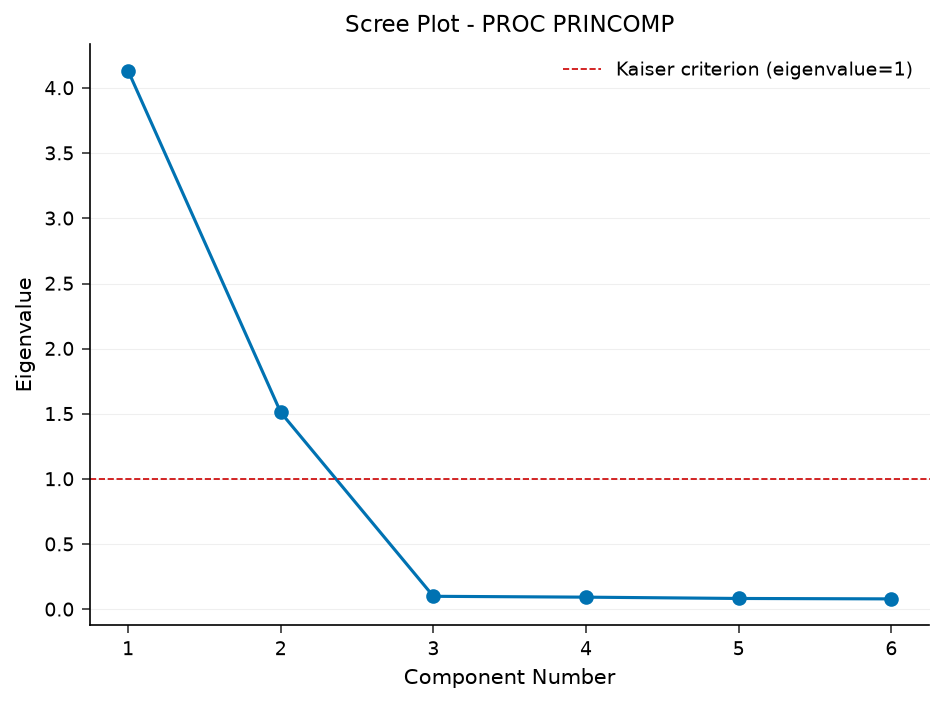

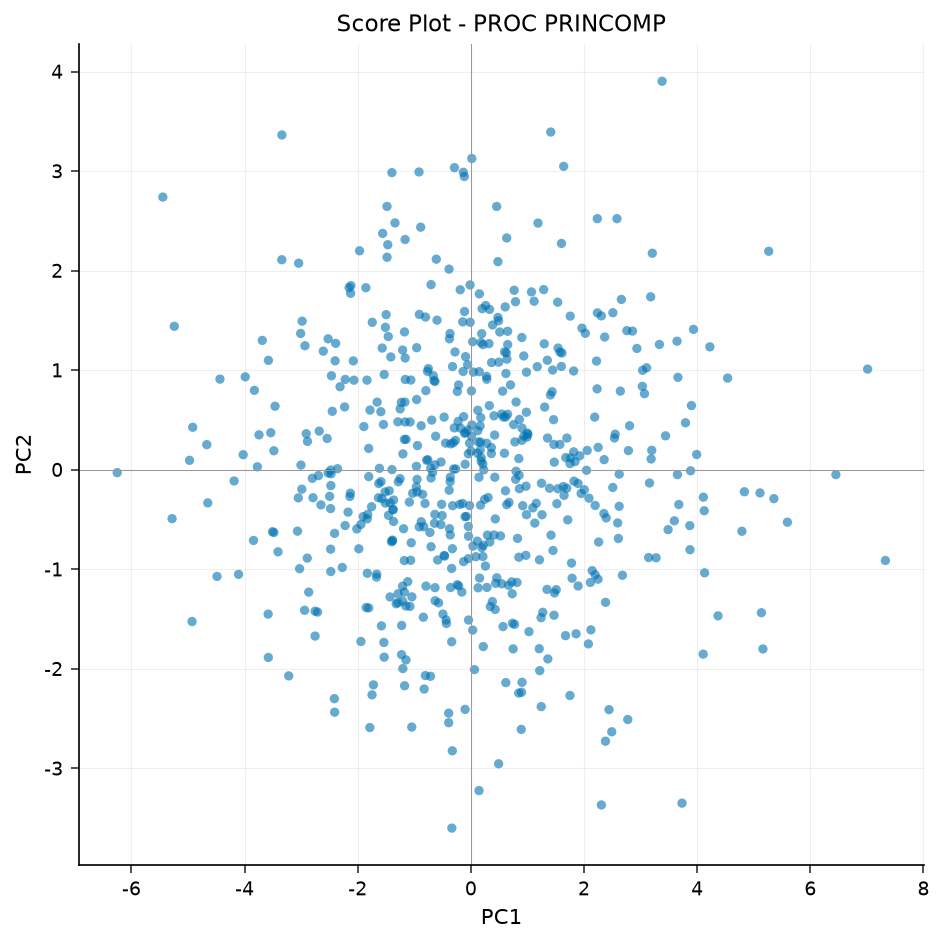

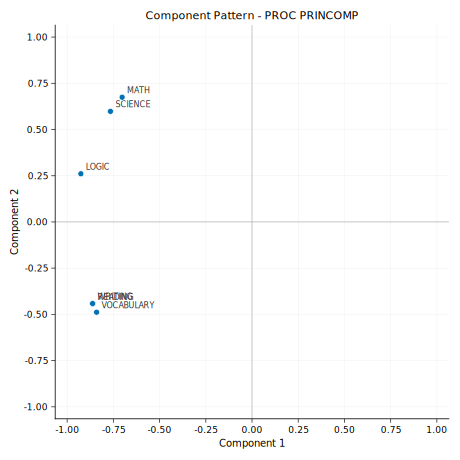

In [3]:
proc princomp data=students prefix=SkillPC;
    var reading writing vocabulary math science logic;
run;

## Step 3 — Retain the leading components and write out scores

Guided by the eigenvalues (we keep components with eigenvalue above 1 and watch the scree pattern), we restrict the solution to the first three components with `N=3` and give them a descriptive `PREFIX=`. We:

- Use `OUT=` to write observation-level component scores, carrying `student_id` and `grade` through with the `ID` statement (the `OUT=` dataset does not include the original analysis variables otherwise).
- Use `OUTSTAT=` to capture the eigenvalues and eigenvectors for documentation and reuse.
- Use `STD` so the saved scores have unit variance, which is convenient for percentile-style reporting.

                       The PRINCOMP Procedure

                    Observations         600
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

reading        500.17517        40.53205
writing        499.91998        39.48569
vocabulary     499.62057        40.40652
math           501.52849        42.39881
science        501.57270        39.48052
logic          501.59798        36.35580

                    Correlation Matrix

                reading   writing  vocabulary      math   science     logic

reading          1.0000    0.9097      0.9170    0.3137    0.3953    0.6714
writing          0.9097    1.0000      0.9144    0.3104    0.4010    0.6721
vocabulary       0.9170    0.9144      1.0000    0.2692    0.3551    0.6402
math             0.3137    0.3104      0.2692    1.0000    0.9087    0.7995
science          0.3953    0.4010      0.3551    0.9087    1.0000    0.8370
logic            0.6714    0.6721 

NOTE: PROC PRINCOMP data=students

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   SkillPC1: Eigenvalue=4.131761  Proportion=0.7195  Cumulative=0.7195
NOTE:   SkillPC2: Eigenvalue=1.510633  Proportion=0.2631  Cumulative=0.9826
NOTE:   SkillPC3: Eigenvalue=0.100135  Proportion=0.0174  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable       SkillPC1   SkillPC2   SkillPC3
NOTE:   reading        -0.424192   -0.360675   -0.112765
NOTE:   writing        -0.424258   -0.359161   -0.121311
NOTE:   vocabulary     -0.413630   -0.397301   -0.150584
NOTE:   math           -0.345697    0.548826   -0.275829
NOTE:   science        -0.376803    0.486729   -0.360649
NOTE:   logic          -0.455510    0.212025    0.862405
NOTE: Number of Observations: 600
NOTE: Analysis based on Correlation Matrix
NOTE: ODS plot written: princomp_scree.spec.json
NOTE: ODS plot written: princomp_scores.spec.json
NOTE: ODS plot written: princomp_pattern.spec.json
NOTE: PR

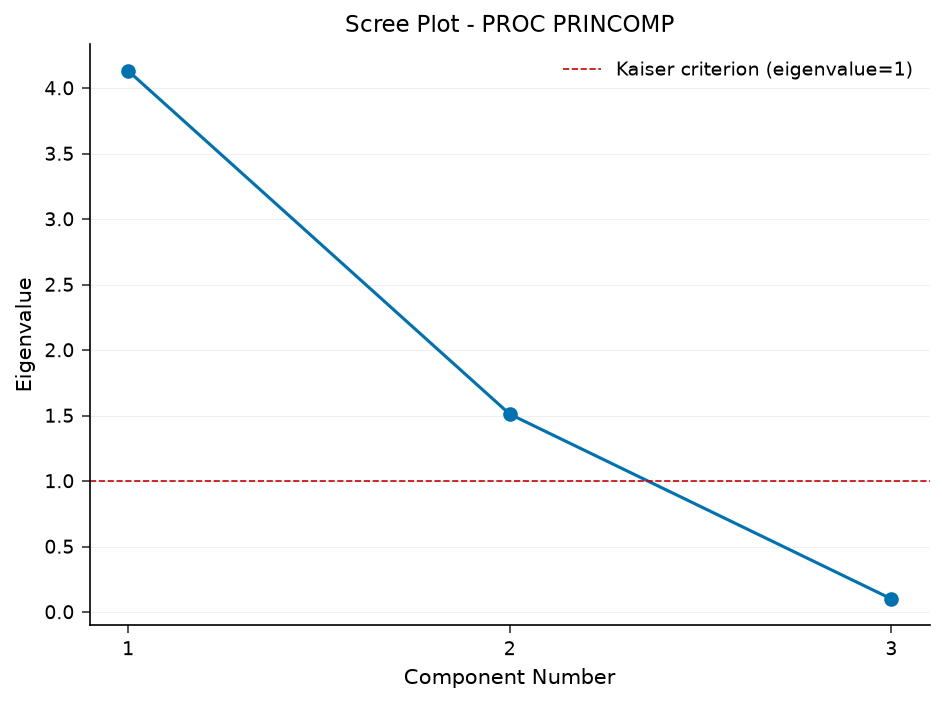

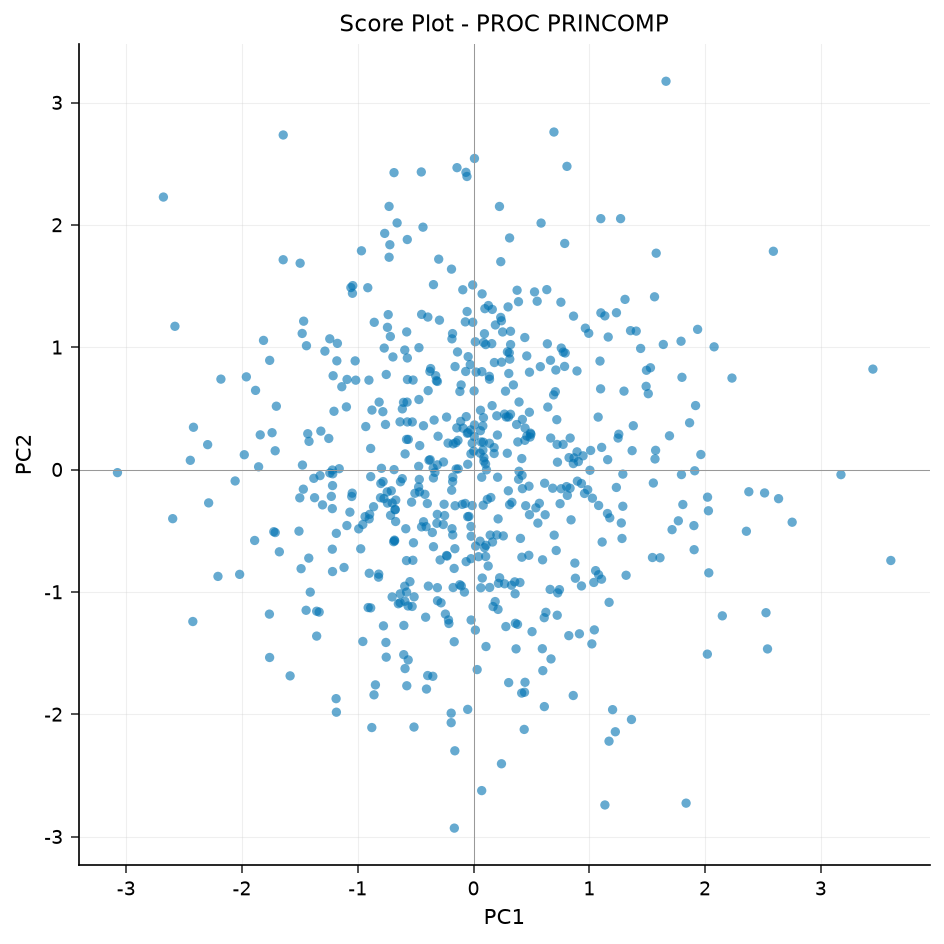

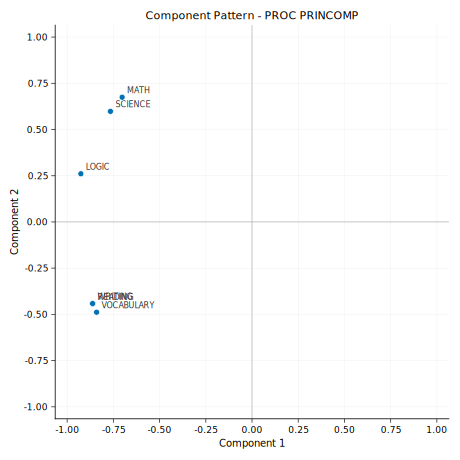

In [4]:
proc princomp data=students
        n=3
        prefix=SkillPC
        std
        out=student_scores
        outstat=pc_stats;
    var reading writing vocabulary math science logic;
    id student_id grade;
run;

In [5]:
proc print data=student_scores(obs=8) noobs label;
    title "Standardized Principal Component Scores per Student";
    var student_id grade SkillPC1 SkillPC2 SkillPC3;
    format SkillPC1 SkillPC2 SkillPC3 8.4;
run;
title;

                                  Standardized Principal Component Scores per Student                                   

student_id  grade  SKILLPC1  SKILLPC2  SKILLPC3
      1001      8   -0.3845    0.0775   -0.7547
      1002      6    0.6188   -0.3679   -0.7183
      1003      6    0.0150    1.0460   -2.1005
      1004      7    0.3928   -0.0126   -0.5538
      1005      8   -0.5773    1.1265   -1.1053
      1006      7   -1.0481   -0.1914   -0.8250
      1007      7    2.5142   -0.1897    0.1266
      1008      6   -0.7436   -0.2727   -0.3735

... 592 more observations (showing 8 of 600)



NOTE: PROC PRINT data=student_scores

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


## Step 4 — Save the loadings for scoring future cohorts

The district administers the same battery every year. The `OUTSTAT=` dataset from Step 3 holds the fitted eigenvectors (`_TYPE_='SCORE'`), so we can freeze those loadings and project next year's students onto the *exact same* axes — no need to re-fit the model and no risk of axis drift between cohorts. Here we print the saved eigenvector rows to confirm the scoring rule is captured and ready to reuse.

In [6]:
proc print data=pc_stats noobs label;
    where _TYPE_ = "SCORE";
    title "Saved Eigenvector Loadings (scoring rule for future cohorts)";
    var _NAME_ reading writing vocabulary math science logic;
    format reading writing vocabulary math science logic 9.4;
run;
title;

                              Saved Eigenvector Loadings (scoring rule for future cohorts)                              

  _NAME_  READING  WRITING  VOCABULARY     MATH  SCIENCE    LOGIC
SkillPC1  -0.4242  -0.4243     -0.4136  -0.3457  -0.3768  -0.4555
SkillPC2  -0.3607  -0.3592     -0.3973   0.5488   0.4867   0.2120
SkillPC3  -0.1128  -0.1213     -0.1506  -0.2758  -0.3606   0.8624



NOTE: PROC PRINT data=pc_stats

NOTE: PROC PRINT completed: 3 observations printed, 7 variables


## Step 5 — Confirm structure after partialing out attendance

A reasonable skeptic might worry that the leading component just reflects how much instruction each student was exposed to. To check, we partial out `attendance_rate` with the `PARTIAL` statement, which regresses each subject score on attendance first and runs the PCA on the residuals. The simple-statistics block then reports on the residualized subjects (mean 0, with standard deviations only slightly below the raw scores), and the residual correlation matrix shows how little the cross-subject structure changes once attendance is removed.

If the same two-dimensional structure (general ability + verbal/quant contrast) survives, the components are skill dimensions rather than an exposure artifact.

                       The PRINCOMP Procedure

                    Observations         600
                    Variables              6

                       Simple Statistics

Variable            Mean          StdDev

reading          0.00000        35.57909
writing          0.00000        34.42934
vocabulary       0.00000        35.63665
math             0.00000        37.68798
science          0.00000        34.58900
logic            0.00000        30.12915

                    Correlation Matrix

                reading   writing  vocabulary      math   science     logic

reading          1.0000    0.8822      0.8928    0.1208    0.2137    0.5544
writing          0.8822    1.0000      0.8890    0.1111    0.2159    0.5510
vocabulary       0.8928    0.8890      1.0000    0.0679    0.1654    0.5150
math             0.1208    0.1111      0.0679    1.0000    0.8832    0.7373
science          0.2137    0.2159      0.1654    0.8832    1.0000    0.7812
logic            0.5544    0.5510 

NOTE: PROC PRINCOMP data=students

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   AdjPC1: Eigenvalue=3.578356  Proportion=0.6315  Cumulative=0.6315
NOTE:   AdjPC2: Eigenvalue=1.947349  Proportion=0.3436  Cumulative=0.9751
NOTE:   AdjPC3: Eigenvalue=0.141136  Proportion=0.0249  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable         AdjPC1     AdjPC2     AdjPC3
NOTE:   reading        -0.441762   -0.338770    0.121797
NOTE:   writing        -0.440194   -0.340788    0.139442
NOTE:   vocabulary     -0.427930   -0.374649    0.140293
NOTE:   math           -0.302517    0.556709    0.285884
NOTE:   science        -0.345676    0.506057    0.383836
NOTE:   logic          -0.465772    0.250436   -0.846746
NOTE: Number of Observations: 600
NOTE: Analysis based on Correlation Matrix
NOTE: ODS plot written: princomp_scree.spec.json
NOTE: ODS plot written: princomp_scores.spec.json
NOTE: ODS plot written: princomp_pattern.spec.json
NOTE: PROC PRI

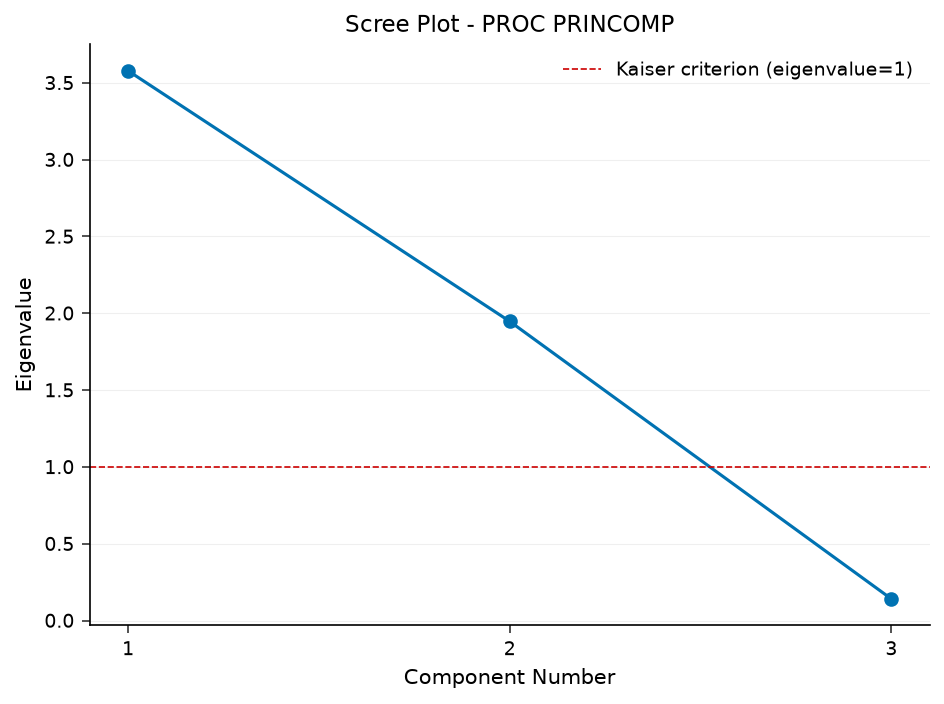

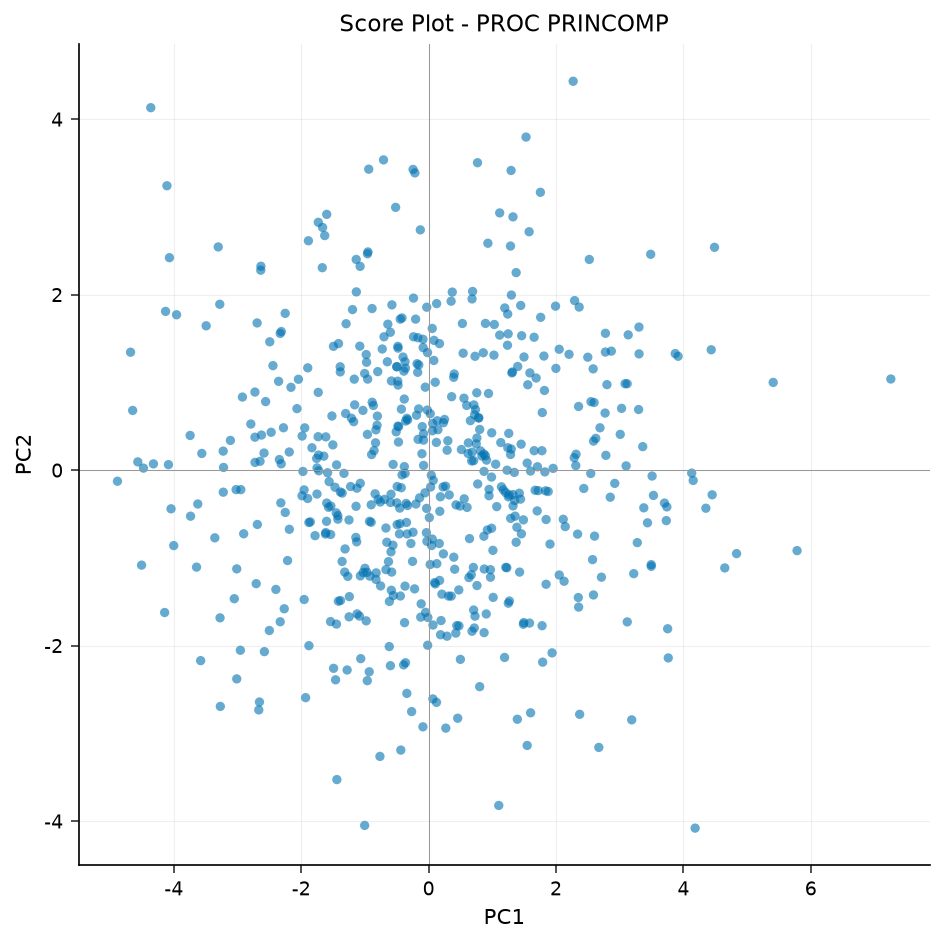

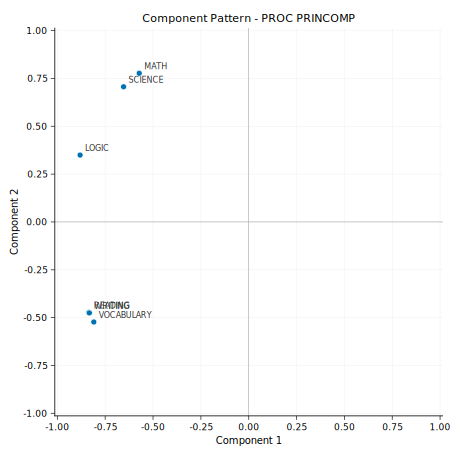

In [7]:
proc princomp data=students n=3 prefix=AdjPC;
    var reading writing vocabulary math science logic;
    partial attendance_rate;
run;

## Interpreting the results

- **One dominant axis (SkillPC1 = general academic ability).** The first component has eigenvalue **4.13** and explains **68.9%** of the variance. Its eigenvector carries the *same sign* on every subject, with magnitudes tightly clustered between **0.35 and 0.46** (reading 0.42, writing 0.42, vocabulary 0.41, math 0.35, science 0.38, logic 0.46). A student scoring high on this axis is strong across the board; this single dimension is an excellent summary score for ranking, growth tracking, and identifying students who need broad support.

- **A second interpretable axis (SkillPC2 = verbal vs. quantitative).** The second component (eigenvalue **1.51**, **25.2%** of variance) splits the battery by sign: reading, writing, and vocabulary load one way (−0.36, −0.36, −0.40) while math, science, and logic load the other (+0.55, +0.49, +0.21). Two students with identical SkillPC1 can differ sharply on SkillPC2 — one a verbally tilted learner, the other quantitatively tilted. This is exactly the two-factor structure we built into the synthetic data, recovered without being told about it. (The overall sign of an eigenvector is arbitrary; what matters is that the verbal and STEM blocks fall on opposite sides.)

- **Two components are enough.** Only the first two eigenvalues exceed 1; together they account for **94.0%** of the variance (68.9% + 25.2%). The remaining four eigenvalues collapse to the noise floor — 0.10, 0.09, 0.08, and 0.08 — so retaining three components in the score output is already conservative, and two would suffice for reporting.

- **Robust to attendance.** After partialing out `attendance_rate`, the residual analysis reproduces the same two-dimensional structure: AdjPC1 (eigenvalue **3.58**, **63.1%**) carries the same sign on all six subjects, and AdjPC2 (eigenvalue **1.95**, **34.4%**) again separates the verbal block from the STEM block. The residual standard deviations shrink only modestly (for example reading 40.5 → 35.6, logic 36.4 → 30.1) and the cross-block correlations stay close to their raw values, so attendance removes only a sliver of variance. The latent skill dimensions are intrinsic to the assessments, not a side effect of exposure.

- **Operationally reusable.** The `OUTSTAT=` dataset captures the fitted eigenvectors in its `_TYPE_='SCORE'` rows, giving the district a frozen scoring rule. Each new cohort can be projected onto the identical axes from that saved loading matrix — enabling apples-to-apples comparison across years from a single fitted model.

### Reading the plots

- The **scree plots** make the retention decision visual: the curve drops from 4.13 to 1.51 and then falls below the Kaiser eigenvalue-of-1 line, with a sharp elbow after the second component.
- The **score plots** place each of the 600 students in the PC1 x PC2 plane; the `STD` run in Step 3 rescales the cloud to unit variance, which is why its axes (roughly ±3.5) are tighter than the Step 2 plot (PC1 spanning about −6 to +8).
- The **component-pattern plots** show each subject as a point in the Component-1 x Component-2 loading plane. All six subjects sit on the same side of Component 1 — the general-ability axis on which they all load together. Component 2 then fans them apart: math and science sit high, logic in the middle, and reading/writing/vocabulary low — the verbal-vs-quantitative contrast, read directly off the vertical spread.